In [16]:
from scipy.stats import cauchy, norm

cauchy.interval(0.975, scale=0.1)[1]
cauchy.interval(0.95, scale=0.01)[1]
norm.interval(0.975, scale=0.1)
# cauchy.interval(0.975, scale=0.001)[1]

(-0.22414027276049453, 0.2241402727604947)

In [76]:
from scipy.stats import cauchy
from scipy.optimize import fsolve
import numpy as np

def get_cauchy_scale(t, alpha):
    epsilon=1e-8
    x = fsolve(lambda x: cauchy.cdf(t, scale=np.log(x)+epsilon) - (1-alpha/2), x0=1.)
    return np.log(x)+epsilon

# Example usage
t = 0.1
alpha = 0.05
gamma = get_cauchy_scale(t, alpha)
print(gamma)

[0.00787017]


In [78]:
cauchy.cdf(t, loc=0, scale=gamma)

array([0.975])

In [81]:
cauchy.cdf(t, loc=0, scale=0.001)

0.9968170072350918

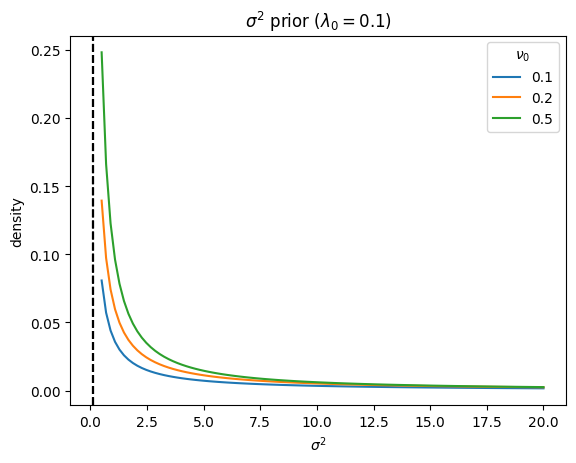

In [66]:
from scipy.stats import invgamma
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.5, 20, num=100)
lambda0 = 0.1

fig, ax = plt.subplots()
for nu0 in [0.1, 0.2, 0.5]:
    precision_p = invgamma.pdf(x, a=nu0 / 2, scale=nu0 * lambda0 / 2)
    ax.plot(x, precision_p, label=nu0)
    ax.legend(title=r"$\nu_0$")
    ax.axvline(lambda0, color="black", linestyle="dashed")
ax.set_xlabel(r"$\sigma^2$")
ax.set_ylabel("density")
ax.set_title(r"$\sigma^2$ prior ($\lambda_0=0.1$)")

plt.show()